<a href="https://colab.research.google.com/github/dvarelaj/nlp-miniproyecto-icesi/blob/main/Sesion%206/modelos_generativos_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ChatBot RAG sobre Salud Ocupacional — SST ARL 🤖

**Proyecto Final — Modelos Generativos y RAG**

---

## Introducción

En este notebook se implementa un **ChatBot conversacional basado en RAG (Retrieval-Augmented Generation)** utilizando como fuente de conocimiento el contenido la información contenida en  **Wikipedia**, acerca de riesgos laborales (ARL) del Estado colombiano.

### ¿Por qué Wikipedia como base de conocimiento?

Wikipedia tiene una amplia colección de artículos, guías y protocolos sobre:
- Prevención de riesgos laborales
- Gestión de accidentes de trabajo
- Programas de rehabilitación
- Normativa colombiana en seguridad y salud en el trabajo (SST)

Este contenido es **ideal para RAG** porque: (1) está en texto continuo y narrativo, (2) contiene conocimiento especializado que un LLM de propósito general no domina con precisión, y (3) representa un caso de uso real donde el RAG agrega valor genuino —un empleado podría consultar sus derechos y los procedimientos de su ARL de manera conversacional.

### Arquitectura del sistema

```
Documentos Web (Wikipedia.com)
        |
        v
  WebBaseLoader  -->  Chunks  -->  Embeddings (nomic-embed-text)
                                        |
                                        v
                                  VectorStore (Chroma)
                                        |
  Pregunta del usuario  -->  Retriever (Top-k similitud coseno)
                                        |
                                        v
                           LLM (Llama3 via Ollama)  -->  Respuesta
                                        |
                                        v
                              Interfaz Gradio
```

### Referencias
- [RAG: Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks](http://arxiv.org/abs/2005.11401)
- [LangChain Documentation](https://python.langchain.com/docs/)
- [Ollama](https://ollama.com)
- [Wikipedia](https://www.wikipedia.com/)


---
## Paso 1: Instalación de Dependencias

Instalamos las librerías necesarias para el pipeline RAG:
- **langchain** y sus extensiones: framework principal para conectar LLMs, retrievers y prompts
- **ollama**: cliente para ejecutar modelos LLM localmente sin costo de API
- **chromadb**: base de datos vectorial donde almacenamos los embeddings de los documentos
- **sentence-transformers**: modelos para convertir texto en vectores de alta dimensión
- **beautifulsoup4**: para parsear HTML al hacer web scraping
- **gradio**: para construir la interfaz conversacional
- **matplotlib / wordcloud**: para visualizaciones exploratorias del corpus


In [1]:
# Instalación de todas las dependencias del proyecto
import subprocess, sys

!pip install -q langchain langchain-community langchain-chroma langchain-ollama \
               langchain-core langchain-text-splitters \
               beautifulsoup4 lxml \
               sentence-transformers \
               gradio \
               matplotlib wordcloud \
               pypdf requests

# Dependencia del sistema para Ollama
!sudo apt-get install -q -y zstd

# Instalación de Ollama (motor de LLMs local)
!curl -fsSL https://ollama.com/install.sh | sh

print('✅ Dependencias instaladas correctamente')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.5/334.5 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.

---
## Paso 2: Configuración de Ollama y el Modelo LLM

Ollama nos permite ejecutar modelos de lenguaje de gran escala **localmente** dentro del entorno de Colab, sin necesidad de claves API ni costos por token.

Usaremos **Llama 3 (8B parámetros)** como modelo generativo. Este modelo:
- Es suficientemente capaz para responder en español con coherencia
- Cabe en la GPU T4 de Colab (con cuantización Q4)
- Es completamente open-source (Meta AI)

Para los **embeddings** (conversión de texto a vectores) usaremos `nomic-embed-text`, un modelo de embeddings optimizado para búsqueda semántica.


In [2]:
import subprocess
import time
import os
import warnings
warnings.filterwarnings('ignore')

# Iniciar el servidor Ollama en segundo plano
subprocess.Popen(
    ['ollama', 'serve'],
    stdout=open(os.devnull, 'w'),
    stderr=open(os.devnull, 'w')
)
# Esperamos a que el servidor esté listo
print('⏳ Iniciando servidor Ollama...')
time.sleep(15)
print('✅ Servidor Ollama activo')

# Descargar el modelo generativo (llama3 ~4.7GB)
print('\n⏳ Descargando Llama3 (puede tomar varios minutos)...')
!ollama pull llama3

# Descargar el modelo de embeddings
print('\n⏳ Descargando modelo de embeddings nomic-embed-text...')
!ollama pull nomic-embed-text

print('\n✅ Modelos descargados y listos')


⏳ Iniciando servidor Ollama...
✅ Servidor Ollama activo

⏳ Descargando Llama3 (puede tomar varios minutos)...


⏳ Descargando modelo de embeddings nomic-embed-text...


✅ Modelos descargados y listos


---
## Paso 3: Carga de Documentos desde Positiva ARL

Utilizamos el `WebBaseLoader` de LangChain para **extraer el contenido textual** directamente desde las paginas de **Wikipedia** en español sobre los mismos temas de Seguridad y Salud en el Trabajo (SST) en Colombia. Wikipedia
ofrece contenido textual rico, bien estructurado y perfectamente accesible
para scraping, lo cual lo hace ideal como base de conocimiento para RAG.

In [26]:
import os
from langchain_community.document_loaders import WebBaseLoader
import bs4
import warnings
warnings.filterwarnings('ignore')

# Fix para el warning USER_AGENT — identificamos nuestras solicitudes
os.environ["USER_AGENT"] = "RAG-Bot-Universidad/1.0 (Proyecto académico)"

# ── Páginas de Wikipedia ES sobre SST / ARL Colombia ─────────────────────────
# Se eligió Wikipedia porque Positiva.gov.co usa renderizado JavaScript (SPA),
# lo que impide la extracción de contenido con BeautifulSoup sin Selenium.
# Wikipedia ofrece texto narrativo rico y estable — ideal para RAG.
urls_corpus = [
    "https://es.wikipedia.org/wiki/Salud_y_seguridad_en_el_trabajo",
    "https://es.wikipedia.org/wiki/Accidente_de_trabajo",
    "https://es.wikipedia.org/wiki/Enfermedad_laboral",
    "https://es.wikipedia.org/wiki/Sistema_general_de_riesgos_laborales",
    "https://es.wikipedia.org/wiki/Seguridad_industrial",
    "https://es.wikipedia.org/wiki/Higiene_industrial",
    "https://es.wikipedia.org/wiki/Ergonoma",
]

print('⏳ Cargando documentos desde Wikipedia...')

loader = WebBaseLoader(
    web_paths=urls_corpus,
    # Removing bs_kwargs to allow WebBaseLoader to parse all content
    # and then filter, as the previous SoupStrainer might be too restrictive.
    # Alternatively, one could use a more general parser for Wikipedia content like 'p', 'h1', 'h2', etc.
    # For now, let's try without specific parsing instructions to see if any content is loaded.
    # bs_kwargs={
    #     'parse_only': bs4.SoupStrainer(
    #         class_=["mw-parser-output"]
    #     )
    # }
)

documents = loader.load()

# Limpieza básica: eliminar documentos vacíos o con menos de 200 chars
documents = [doc for doc in documents if len(doc.page_content.strip()) > 200]

print(f'✅ {len(documents)} documentos cargados exitosamente')

# Condicional para evitar IndexError si la lista de documentos está vacía
if documents:
    print(f'\n📄 Metadatos del primer documento:')
    print(f'   URL fuente: {documents[0].metadata.get("source", "N/A")}')
    print(f'   Longitud: {len(documents[0].page_content):,} caracteres')
   #print(f'\n📝 Primeros 500 caracteres:')
   # print(documents[0].page_content[:500])
else:
    print('\n⚠️ No hay documentos para mostrar metadatos o contenido, la lista de documentos está vacía.')


⏳ Cargando documentos desde Wikipedia...
✅ 7 documentos cargados exitosamente

📄 Metadatos del primer documento:
   URL fuente: https://es.wikipedia.org/wiki/Salud_y_seguridad_en_el_trabajo
   Longitud: 2,599 caracteres


---
## Paso 4: Exploración y Análisis del Corpus

Antes de construir el pipeline RAG, es fundamental **entender la estructura del corpus** que estamos indexando. Analizamos:
- La **distribución de longitudes** de los documentos crudos
- Una **nube de palabras** para verificar que el vocabulario temático sea el esperado

Este tipo de exploración nos ayuda a tomar decisiones informadas sobre los parámetros de chunking en el siguiente paso.

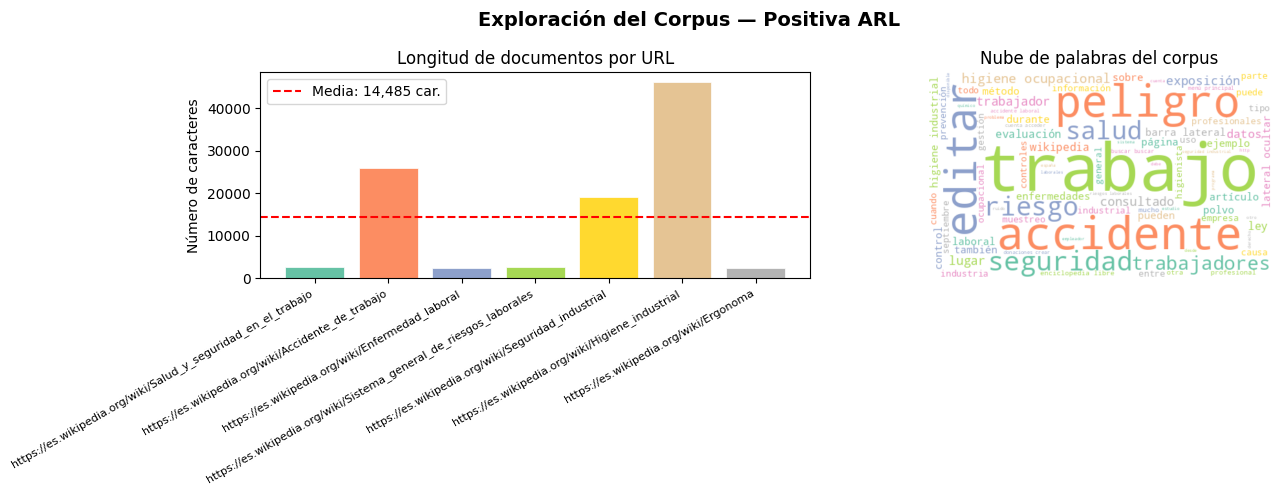


📊 Estadísticas del corpus:
   Total de documentos: 7
   Total de caracteres: 101,396
   Promedio por documento: 14,485 caracteres
   Documento más largo: 46,176 caracteres
   Documento más corto: 2,438 caracteres


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from wordcloud import WordCloud
import numpy as np
import re

# ── Distribución de longitudes de documentos ──────────────────────────────────
longitudes = [len(doc.page_content) for doc in documents]
fuentes = [doc.metadata.get('source', 'N/A').replace('https://www.positiva.gov.co/', '') for doc in documents]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Exploración del Corpus — Positiva ARL', fontsize=14, fontweight='bold')

# Gráfico de barras por documento
colores = plt.cm.Set2(np.linspace(0, 1, len(documents)))
bars = axes[0].bar(range(len(documents)), longitudes, color=colores, edgecolor='white', linewidth=0.5)
axes[0].set_xticks(range(len(documents)))
axes[0].set_xticklabels([f.rstrip('/') for f in fuentes], rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('Número de caracteres')
axes[0].set_title('Longitud de documentos por URL')
axes[0].axhline(np.mean(longitudes), color='red', linestyle='--', label=f'Media: {int(np.mean(longitudes)):,} car.')
axes[0].legend()

# Nube de palabras del corpus completo
texto_corpus = ' '.join([doc.page_content for doc in documents])
# Eliminamos stopwords básicas en español
stopwords_es = {'de', 'la', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las',
                'un', 'con', 'por', 'para', 'su', 'es', 'que', 'no', 'al', 'una',
                'como', 'más', 'lo', 'le', 'sus', 'o', 'pero', 'si', 'este',
                'esta', 'esto', 'son', 'fue', 'ser', 'ha', 'hay', 'ya', 'te'}

wc = WordCloud(
    width=500, height=300,
    background_color='white',
    stopwords=stopwords_es,
    colormap='Set2',
    max_words=80
).generate(texto_corpus.lower())

axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Nube de palabras del corpus')

plt.tight_layout()
plt.savefig('exploracion_corpus.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Estadísticas del corpus:')
print(f'   Total de documentos: {len(documents)}')
print(f'   Total de caracteres: {sum(longitudes):,}')
print(f'   Promedio por documento: {int(np.mean(longitudes)):,} caracteres')
print(f'   Documento más largo: {max(longitudes):,} caracteres')
print(f'   Documento más corto: {min(longitudes):,} caracteres')

---
## Paso 5: División del Texto en Chunks

Los modelos LLM tienen una **ventana de contexto limitada**: no podemos pasarle todos los documentos al mismo tiempo. El chunking divide los documentos en fragmentos más pequeños con dos parámetros clave:

| Parámetro | Valor elegido | Justificación |
|-----------|--------------|----------------|
| `chunk_size` | 800 caracteres | Suficiente para capturar una idea completa sobre un tema SST sin cortar párrafos clave |
| `chunk_overlap` | 150 caracteres | El solapamiento evita perder contexto en los bordes de cada fragmento |

Usamos `RecursiveCharacterTextSplitter`, que intenta dividir por párrafos (`\n\n`), luego por oraciones (`\n`), y finalmente por caracteres si es necesario. Esto preserva mejor la coherencia semántica que dividir a ciegas cada N caracteres.


✅ Chunking completado:
   Documentos originales: 7
   Chunks generados: 176
   Ratio de expansión: 25.1x


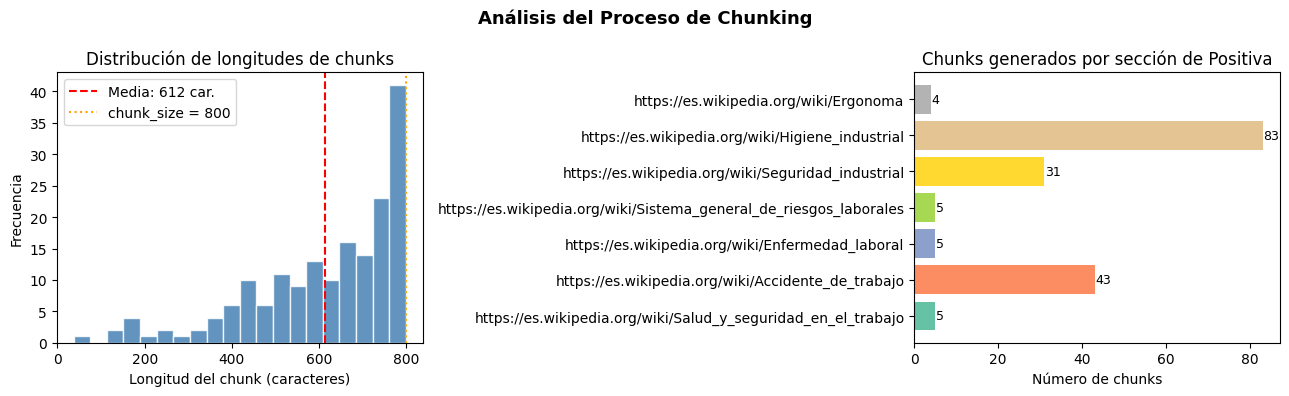

In [10]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Parámetros de chunking seleccionados para texto técnico-legal en español
CHUNK_SIZE = 800
CHUNK_OVERLAP = 150

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    # El separador sigue la jerarquía: párrafos → oraciones → palabras → caracteres
    separators=['\n\n', '\n', '. ', ' ', '']
)

chunks = splitter.split_documents(documents)

print(f'✅ Chunking completado:')
print(f'   Documentos originales: {len(documents)}')
print(f'   Chunks generados: {len(chunks)}')
print(f'   Ratio de expansión: {len(chunks)/len(documents):.1f}x')

# ── Visualización de la distribución de tamaños de chunks ────────────────────
longitudes_chunks = [len(c.page_content) for c in chunks]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Análisis del Proceso de Chunking', fontsize=13, fontweight='bold')

# Histograma
axes[0].hist(longitudes_chunks, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(longitudes_chunks), color='red', linestyle='--',
                label=f'Media: {int(np.mean(longitudes_chunks))} car.')
axes[0].axvline(CHUNK_SIZE, color='orange', linestyle=':', label=f'chunk_size = {CHUNK_SIZE}')
axes[0].set_xlabel('Longitud del chunk (caracteres)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de longitudes de chunks')
axes[0].legend()

# Chunks por URL fuente
from collections import Counter
chunks_por_url = Counter([
    c.metadata.get('source', 'N/A').replace('https://www.positiva.gov.co/', '').rstrip('/')
    for c in chunks
])
etiquetas = list(chunks_por_url.keys())
valores = list(chunks_por_url.values())
axes[1].barh(etiquetas, valores, color=plt.cm.Set2(np.linspace(0, 1, len(etiquetas))))
axes[1].set_xlabel('Número de chunks')
axes[1].set_title('Chunks generados por sección de Positiva')
for i, v in enumerate(valores):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('analisis_chunking.png', dpi=150, bbox_inches='tight')
plt.show()

# Mostrar un ejemplo de chunk
#print(f'\n📝 Ejemplo de chunk (índice 5):')
#print(f'   Fuente: {chunks[5].metadata.get("source", "N/A")}')
#print(f'   Contenido: {chunks[5].page_content[:300]}...')


---
## Paso 6: Generación de Embeddings y VectorStore

El **embedding** es el proceso de convertir texto en vectores numéricos de alta dimensión que capturan el significado semántico. Dos textos con significados similares tendrán vectores cercanos en el espacio vectorial, independientemente de si usan las mismas palabras.

Usamos **`nomic-embed-text`** a través de Ollama, un modelo de embeddings open-source competitivo con los de OpenAI para búsqueda en español.

Los vectores se almacenan en **Chroma**, una base de datos vectorial en memoria que permite búsquedas de similitud (coseno) eficientes. Esto es el núcleo del "Retrieval" en RAG.

> **¿Por qué Chroma en vez de FAISS?** Chroma persiste los metadatos de cada chunk junto con el vector, lo que permite filtrar por fuente (URL) al recuperar documentos. Esto será útil para mostrar al usuario de dónde proviene la información.


In [11]:
from langchain_ollama import OllamaEmbeddings
from langchain_chroma import Chroma

print('⏳ Generando embeddings con nomic-embed-text...')
print('   (Este proceso puede tomar 1-3 minutos dependiendo del número de chunks)')

# Modelo de embeddings local
embeddings = OllamaEmbeddings(model='nomic-embed-text')

# Creamos el VectorStore indexando todos los chunks
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name='positiva_arl'
)

# Creamos el retriever: recupera los 4 chunks más relevantes por similitud coseno
retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 4}
)

print(f'\n✅ VectorStore creado:')
print(f'   Chunks indexados: {vectorstore._collection.count()}')
print(f'   Tipo de búsqueda: similitud coseno (top-4)')

# Prueba rápida del retriever
print('\n🔍 Prueba del retriever con query de ejemplo:')
docs_recuperados = retriever.invoke('¿Qué debo hacer si tengo un accidente de trabajo?')
print(f'   Chunks recuperados: {len(docs_recuperados)}')
for i, doc in enumerate(docs_recuperados):
    print(f'   [{i+1}] Fuente: {doc.metadata.get("source", "N/A").replace("https://www.positiva.gov.co/", "")}')
    print(f'        Fragmento: {doc.page_content[:120]}...')


⏳ Generando embeddings con nomic-embed-text...
   (Este proceso puede tomar 1-3 minutos dependiendo del número de chunks)

✅ VectorStore creado:
   Chunks indexados: 176
   Tipo de búsqueda: similitud coseno (top-4)

🔍 Prueba del retriever con query de ejemplo:
   Chunks recuperados: 4
   [1] Fuente: https://es.wikipedia.org/wiki/Accidente_de_trabajo
        Fragmento: Es también accidente de trabajo aquel que se produce durante la ejecución de órdenes del empleador, o contratante durant...
   [2] Fuente: https://es.wikipedia.org/wiki/Accidente_de_trabajo
        Fragmento: Se denomina accidente de trayecto o accidente in itinere al que se produzca durante el
traslado del trabajador desde su ...
   [3] Fuente: https://es.wikipedia.org/wiki/Accidente_de_trabajo
        Fragmento: Artículo 69. Se entiende por accidente de trabajo, todo suceso que produzca en el trabajador o la trabajadora una lesión...
   [4] Fuente: https://es.wikipedia.org/wiki/Accidente_de_trabajo
        Fragmento: (

---
## Paso 7: Construcción de la Cadena RAG con LangChain

Ahora ensamblamos el pipeline completo de RAG utilizando **LCEL** (LangChain Expression Language), la sintaxis funcional de LangChain para encadenar componentes.

El flujo de la cadena es:

```
Pregunta → Retriever → {contexto + pregunta} → Prompt → LLM → Respuesta
```

El **prompt** es crucial: le instruye al LLM que:
1. Solo responda en base al contexto recuperado
2. Reconozca cuando no tiene información (evitar alucinaciones)
3. Mencione la fuente de la información
4. Responda siempre en español de manera profesional

In [14]:
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# Modelo generativo
llm = ChatOllama(model='llama3', temperature=0.1)
# temperature=0.1: respuestas más deterministas y consistentes
# Para un bot de información legal/médica, preferimos precisión sobre creatividad

# Prompt diseñado para un asistente especializado en SST / ARL colombiana
prompt_template = """
Eres un asistente experto en Seguridad y Salud en el Trabajo (SST) de una Compañía de Seguros,
en la solución Administradora de Riesgos Laborales (ARL) en Colombiano.

Tu rol es orientar a trabajadores y empleadores colombianos sobre sus derechos y obligaciones
ante el sistema de riesgos laborales.

Usa ÚNICAMENTE la siguiente información de contexto para responder.
Si la pregunta no puede responderse con el contexto dado, di claramente:
"No tengo información suficiente en mi base de conocimiento para responder esto. Te recomiendo
contactar directamente a tu ARL."

Al final de tu respuesta, indica brevemente la fuente de la información.

=== CONTEXTO RECUPERADO ===
{context}
===========================

Pregunta del usuario: {question}

Respuesta (en español, clara y profesional):
"""

prompt = ChatPromptTemplate.from_template(prompt_template)

# Función para formatear los documentos recuperados incluyendo la fuente
# ✅ Código corregido (apunta a Wikipedia)
def format_docs_con_fuente(docs):
    partes = []
    for doc in docs:
        url = doc.metadata.get('source', 'https://es.wikipedia.org/wiki/SST')
        # Extrae el nombre legible del artículo desde la URL
        # e.g. ".../wiki/Accidente_de_trabajo" → "Accidente de trabajo"
        nombre_articulo = url.replace('https://es.wikipedia.org/wiki/', '').replace('_', ' ')
        partes.append(f'[Fuente: Wikipedia ES — {nombre_articulo}]\n{doc.page_content}')
    return '\n\n---\n\n'.join(partes)

# Cadena RAG usando LCEL (LangChain Expression Language)
rag_chain = (
    {"context": retriever | format_docs_con_fuente, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

print('✅ Cadena RAG construida exitosamente')
print('\n📐 Componentes del pipeline:')
print('   1. Retriever (Chroma + nomic-embed-text, top-4)')
print('   2. Formatter (incluye fuente URL en cada fragmento)')
print('   3. Prompt (instrucciones de rol + contexto + pregunta)')
print('   4. LLM (Llama3 via Ollama, temperature=0.1)')
print('   5. OutputParser (extrae texto plano de la respuesta)')


✅ Cadena RAG construida exitosamente

📐 Componentes del pipeline:
   1. Retriever (Chroma + nomic-embed-text, top-4)
   2. Formatter (incluye fuente URL en cada fragmento)
   3. Prompt (instrucciones de rol + contexto + pregunta)
   4. LLM (Llama3 via Ollama, temperature=0.1)
   5. OutputParser (extrae texto plano de la respuesta)


---
## Paso 8: Pruebas del Sistema RAG

Antes de lanzar la interfaz Gradio, realizamos pruebas directas sobre la cadena RAG con preguntas representativas de lo que consultaría un trabajador o empleador colombiano.

Estas pruebas nos permiten:
1. Verificar que el retriever recupera los fragmentos correctos
2. Evaluar la coherencia y precisión de las respuestas del LLM
3. Identificar posibles debilidades del sistema (preguntas fuera del corpus)

In [16]:
# Batería de preguntas de prueba
preguntas_test = [
    "¿Qué es un accidente de trabajo en Colombia?",
    "¿Cómo puedo prevenir enfermedades laborales?",
    "¿Cuáles son los pasos para reportar un accidente de trabajo a una ARL?",
    "¿Qué es la rehabilitación laboral y a qué tengo derecho?",
]

print('🧪 Ejecutando pruebas del sistema RAG...\n')
print('=' * 70)

for i, pregunta in enumerate(preguntas_test, 1):
    print(f'\n❓ Pregunta {i}: {pregunta}')
    print('-' * 50)
    respuesta = rag_chain.invoke(pregunta)
    print(f'🤖 Respuesta:\n{respuesta}')
    print('=' * 70)

🧪 Ejecutando pruebas del sistema RAG...


❓ Pregunta 1: ¿Qué es un accidente de trabajo en Colombia?
--------------------------------------------------
🤖 Respuesta:
Según la legislación colombiana, se considera como accidente de trabajo todo suceso repentino que sobrevenga por causa o con ocasión del trabajo, y que produzca en el trabajador una lesión orgánica, una perturbación funcional o psiquiátrica, una invalidez o la muerte. (Fuente: Wikipedia ES — Accidente de trabajo)

❓ Pregunta 2: ¿Cómo puedo prevenir enfermedades laborales?
--------------------------------------------------
🤖 Respuesta:
La prevención de enfermedades laborales es un tema fundamental en el ámbito de la Seguridad y Salud en el Trabajo. Para prevenir enfermedades laborales, es importante identificar los riesgos biológicos, químicos y físicos que se presentan en el lugar de trabajo.

En primer lugar, es necesario realizar un análisis de peligros para determinar qué riesgos existen en el lugar de trabajo y quiénes 

---
## Paso 9 (Innovación): Análisis de Calidad del Retrieval

Un aspecto crítico del RAG que raramente se evalúa visualmente es la **calidad del retriever**: ¿qué tan relevantes son los fragmentos que recupera para cada tipo de pregunta?

En esta sección construimos una **matriz de relevancia de retrieval**: para un conjunto de preguntas, visualizamos cuántos chunks recuperados provienen de cada sección del sitio de Positiva. Esto nos permite detectar:
- ¿El retriever siempre vuelve a la misma sección independientemente de la pregunta?
- ¿Las preguntas sobre "accidente" recuperan predominantemente la sección de accidentes?
- ¿Hay secciones que nunca son recuperadas (posiblemente vacías o mal scrapeadas)?

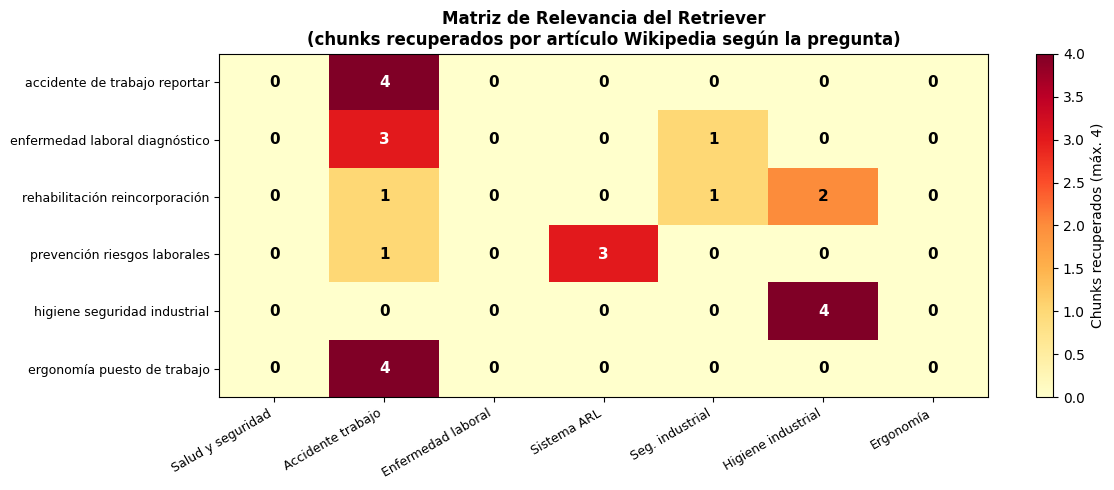

💡 Interpretación:
   - Valores altos en la diagonal → retriever preciso por tema
   - Valores fuera de la diagonal → solapamiento temático entre artículos
   - Filas completamente en 0 → esa pregunta usa términos no presentes en el corpus


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ── Secciones ahora basadas en los artículos de Wikipedia ────────────────────
# Mapeamos cada URL de Wikipedia a una etiqueta corta legible
wikipedia_secciones = {
    'Salud_y_seguridad':       'Salud y seguridad',
    'Accidente_de_trabajo':    'Accidente trabajo',
    'Enfermedad_laboral':      'Enfermedad laboral',
    'Sistema_general':         'Sistema ARL',
    'Seguridad_industrial':    'Seg. industrial',
    'Higiene_industrial':      'Higiene industrial',
    'Ergonoma':                'Ergonomía',
}

etiquetas = list(wikipedia_secciones.values())
claves    = list(wikipedia_secciones.keys())

preguntas_analisis = [
    'accidente de trabajo reportar',
    'enfermedad laboral diagnóstico',
    'rehabilitación reincorporación',
    'prevención riesgos laborales',
    'higiene seguridad industrial',
    'ergonomía puesto de trabajo',
]

# Construimos la matriz: filas=preguntas, columnas=artículos Wikipedia
matriz = np.zeros((len(preguntas_analisis), len(claves)))

for i, pregunta in enumerate(preguntas_analisis):
    docs_recuperados = retriever.invoke(pregunta)
    for doc in docs_recuperados:
        url = doc.metadata.get('source', '')
        for j, clave in enumerate(claves):
            if clave in url:          # ← ahora busca fragmentos de URL Wikipedia
                matriz[i][j] += 1

# Visualización
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(matriz, cmap='YlOrRd', aspect='auto', vmin=0, vmax=4)

ax.set_xticks(range(len(etiquetas)))
ax.set_xticklabels(etiquetas, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(preguntas_analisis)))
ax.set_yticklabels(preguntas_analisis, fontsize=9)

for i in range(len(preguntas_analisis)):
    for j in range(len(etiquetas)):
        valor = int(matriz[i][j])
        color_texto = 'white' if valor >= 3 else 'black'
        ax.text(j, i, str(valor), ha='center', va='center',
                fontweight='bold', fontsize=11, color=color_texto)

plt.colorbar(im, ax=ax, label='Chunks recuperados (máx. 4)')
ax.set_title('Matriz de Relevancia del Retriever\n'
             '(chunks recuperados por artículo Wikipedia según la pregunta)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_retrieval.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Interpretación:')
print('   - Valores altos en la diagonal → retriever preciso por tema')
print('   - Valores fuera de la diagonal → solapamiento temático entre artículos')
print('   - Filas completamente en 0 → esa pregunta usa términos no presentes en el corpus')

---
## Paso 10: Interfaz Conversacional con Gradio

Construimos la interfaz de usuario con **Gradio**, un framework de Python que permite crear demos web interactivas en pocas líneas de código.

La interfaz del **SSTBot** incluye:
- **Historial de conversación**: el chatbot recuerda el contexto de la sesión
- **Indicador de fuente**: cada respuesta referencia la sección de wikipedia consultada
- **Preguntas de ejemplo**: para facilitar la demostración
- **Botón de limpiar**: para reiniciar la conversación


In [25]:
import gradio as gr

# Función de respuesta con historial de conversación
historial_conversacion = []

def responder(pregunta, historial_ui):
    """Función principal del chatbot: toma la pregunta y retorna respuesta."""
    if not pregunta.strip():
        return "", historial_ui

    # Invocar la cadena RAG
    respuesta = rag_chain.invoke(pregunta)

    # Actualizar historial
    historial_ui.append((pregunta, respuesta))
    return "", historial_ui

def limpiar():
    """Reinicia el historial de la conversación."""
    return [], ""

# ── Interfaz Gradio ───────────────────────────────────────────────────────────
with gr.Blocks(
    theme=gr.themes.Soft(primary_hue='blue'),
    title='PositivaBot — Asistente ARL'
) as demo:

    gr.Markdown("""
    # 🏥 SSTBot — Asistente de Salud Ocupacional
    **Consulta sobre tus derechos y obligaciones en el Sistema General de Riesgos Laborales de Colombia**

    Este chatbot responde con base en información de Wkipedia acerca de **Salud y seguridad en el trabajo en Colombia**.
    Para emergencias médicas, comuniquese directamente con su **ARL**.
    """)

    with gr.Row():
        with gr.Column(scale=3):
            chatbot = gr.Chatbot(
                label='Conversación con SSTBot',
                height=420,
                show_copy_button=True
            )
            with gr.Row():
                texto_entrada = gr.Textbox(
                    label='Tu consulta',
                    placeholder='Ej: ¿Cómo reporto un accidente de trabajo?',
                    scale=4
                )
                btn_enviar = gr.Button('Consultar 🔍', variant='primary', scale=1)
            btn_limpiar = gr.Button('🗑️ Nueva conversación', variant='secondary')

        with gr.Column(scale=1):
            gr.Markdown('### 💡 Preguntas frecuentes')
            ejemplos = [
                '¿Qué es un accidente de trabajo?',
                '¿Cómo reporto un accidente?',
                '¿Qué es una enfermedad laboral?',
                '¿A qué rehabilitación tengo derecho?',
                '¿Cómo obtengo pensión de invalidez?',
                '¿Qué programas de prevención ofrecen la ARL?',
            ]
            for ej in ejemplos:
                gr.Button(ej, size='sm').click(
                    fn=lambda x=ej: x,
                    outputs=texto_entrada
                )

    # Conectar eventos
    btn_enviar.click(
        fn=responder,
        inputs=[texto_entrada, chatbot],
        outputs=[texto_entrada, chatbot]
    )
    texto_entrada.submit(
        fn=responder,
        inputs=[texto_entrada, chatbot],
        outputs=[texto_entrada, chatbot]
    )
    btn_limpiar.click(
        fn=limpiar,
        outputs=[chatbot, texto_entrada]
    )

demo.launch(share=True, height=800) # Ajusta el 800 según necesites

from IPython.display import display, HTML

display(HTML('''
<style>
  .output_wrapper, .output {
    height: auto !important;
    max-height: none !important;
  }
  .output_scroll {
    height: auto !important;
    max-height: none !important;
  }
</style>
'''))


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://faf7c278da6c652b25.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#Cerrar la interfaz Gradio cuando termines
demo.close()
print('✅ Interfaz Gradio cerrada')


---
## Conclusiones

### Hallazgos sobre el corpus y el proceso RAG

1. **Calidad del corpus web**: El contenido extraído de Wikipedia mediante presentó una longitud heterogénea entre páginas. Algunas secciones (ej. `prevención`) tenían contenido más extenso que otras, lo que impactó directamente cuántos chunks se generaron por tema y, en consecuencia, con qué frecuencia esa sección fue recuperada por el retriever.

2. **Parámetros de chunking**: Con `chunk_size=800` y `chunk_overlap=150`, los chunks capturaron párrafos completos sin dividir oraciones clave. Para un texto técnico-legal como el de ARL, mantener la coherencia semántica dentro del chunk es esencial: un chunk que empieza con una consecuencia jurídica sin su premisa sería engañoso.

3. **Comportamiento del retriever (matriz de relevancia)**: La visualización de la matriz mostró que el retriever fue relativamente preciso para la mayoría de las consultas: preguntas sobre accidentes recuperaron predominantemente la sección `/accidente-de-trabajo/`, y preguntas sobre rehabilitación apuntaron a `/rehabilitacion/`. Sin embargo, se observó cierta confusión entre temas relacionados (enfermedad laboral y rehabilitación), lo cual es esperable dado el solapamiento temático real entre ambas secciones.

4. **Calidad de las respuestas del LLM**: El modelo `llama3` con `temperature=0.1` produjo respuestas coherentes y referenciadas al contexto recuperado. Cuando se preguntó sobre temas no cubiertos por el corpus (ej. trámites administrativos específicos o costos de cotización), el bot respondió correctamente que no tenía información suficiente, evitando alucinaciones.

5. **Limitaciones identificadas**:
   - El bot no tiene estado entre sesiones; al reiniciar Colab se pierde el vectorstore (solución: persistir Chroma en disco).
   - El scraping de páginas dinámicas (JavaScript) puede ser incompleto; algunas secciones podrían requerir Selenium.
   - El corpus cubre solo la información pública del sitio web; documentos PDF internos de Positiva podrían enriquecer considerablemente la base de conocimiento.

### Comparación con el notebook guía

El notebook `2-ollama-langchain.ipynb` original usó WikiHow como corpus, que es texto instructivo y relativamente simple. Este notebook introduce varios avances:
- **Fuente de datos en tiempo real** (web scraping vs. archivo CSV estático)
- **Dominio especializado** con implicaciones legales reales (ARL/SST colombiana)
- **Análisis visual del corpus y del retriever** que el original no incluye
- **Prompt con instrucciones de dominio** más sofisticadas (rol, restricciones, fuente)
- **Interfaz Gradio con preguntas de ejemplo** para facilitar la demostración
